## Load packages and define functions

In [2]:
import pandas as pd 
import pyam
import matplotlib.pyplot as plt
import pandas_indexing as pix
from pandas_indexing import isin, ismatch
import numpy as np

import os
from pathlib import Path

from fuzzywuzzy import fuzz

import warnings
warnings.simplefilter(action='ignore', category=FutureWarning)

import data_shepherd as ds
from data_shepherd import utils
import datatoolbox as dt

<IPython.core.display.Javascript object>

In [3]:
def elec(tech=None):
    if not tech is None:
        return f'Secondary Energy|Electricity|{tech}'
    else:
        return 'Secondary Energy|Electricity'

In [4]:
REMIND_RMAP = ds.utils.RegionMapping.from_model('REMIND_2.1')
REMIND_RMAP

RegionMapping(model_name='REMIND_2.1', iso_to_region=ISO
ABW    LAM
AFG    OAS
AGO    SSA
AIA    LAM
ALA    EUR
      ... 
WSM    OAS
YEM    MEA
ZAF    SSA
ZMB    SSA
ZWE    SSA
Name: REMIND_2.1.REGION, Length: 246, dtype: object, region_names={'LAM': 'Latin America and the Caribbean', 'OAS': 'Other Asia', 'SSA': 'Sub-Saharan Africa', 'EUR': 'EU28', 'NEU': 'Europe (non-EU28)', 'MEA': 'Middle East and North Africa', 'REF': 'Russia', 'CAZ': 'Canada, Australia and New Zealand', 'CHA': 'China', 'IND': 'India', 'JPN': 'Japan', 'USA': 'USA'})

In [123]:
IKEA_ISOS = ["DEU","POL","BRA","MEX","KEN","MAR","MOZ",#"EU27",
             "NGA","SEN","ZAF","USA","NAM","DZA","TUR","SAU",
             "ARE","BGD","IND","IDN","PAK","VNM","GBR","AUS","CHN","JPN"]

IKEA_ISOS.sort()

## Load data

In [6]:
BOX_MOUNT_PATH = Path("~/Library/CloudStorage/Box-Box").expanduser()
if not BOX_MOUNT_PATH.is_dir():
    BOX_MOUNT_PATH = Path("~/Box").expanduser()

In [7]:
DSCALE_PATH = (
    "Climate Policy Team/"
    "02 - Projects/"
    "IKEA NDC 1.5° Pathways 23-25 - phase II/"
    "2 - Work Packages/"
    "WP2 - National 1.5°C Pathways/"
    "Downscaling/"
    "DSCALE"
)

DSCALE_PATH: os.PathLike = BOX_MOUNT_PATH / DSCALE_PATH

In [8]:
REMIND_PATH = (
    "Climate Policy Team/"
    "02 - Projects/"
    "IKEA NDC 1.5° Pathways 23-25 - phase II/"
    "2 - Work Packages/"
    "WP1 - Updating global 1.5°C Pathways/"
    "1 - PIK/"
    "Scenario Data/"
    "SUBMITTED_SCENARIOS_August2025/"

)

REMIND_PATH: os.PathLike = BOX_MOUNT_PATH / REMIND_PATH

In [58]:
NPE_PATH = (
    "Climate Policy Team/"
    "02 - Projects/"
    "IKEA NDC 1.5° Pathways 23-25 - phase II/"
    "2 - Work Packages/"
    "WP2 - National 1.5°C Pathways/"
    "Country assessment"

)

NPE_PATH: os.PathLike = BOX_MOUNT_PATH / NPE_PATH

In [9]:
input_data = pyam.IamDataFrame(REMIND_PATH / 'ar6_templates/REMIND-MAgPIE_coreAndVariations_2025-12-10_16.07.26.xlsx')

pyam - INFO: Running in a notebook, setting up a basic logging at level INFO
pyam.core - INFO: Reading file /Users/marie-charlottegeffray/Library/CloudStorage/Box-Box/Climate Policy Team/02 - Projects/IKEA NDC 1.5° Pathways 23-25 - phase II/2 - Work Packages/WP1 - Updating global 1.5°C Pathways/1 - PIK/Scenario Data/SUBMITTED_SCENARIOS_August2025/ar6_templates/REMIND-MAgPIE_coreAndVariations_2025-12-10_16.07.26.xlsx


In [10]:
hist_data_iea = pyam.IamDataFrame(DSCALE_PATH /  'data/step1_input_data_for_DSCALE/input_reference_iea_2022.csv')

pyam.core - INFO: Reading file /Users/marie-charlottegeffray/Library/CloudStorage/Box-Box/Climate Policy Team/02 - Projects/IKEA NDC 1.5° Pathways 23-25 - phase II/2 - Work Packages/WP2 - National 1.5°C Pathways/Downscaling/DSCALE/data/step1_input_data_for_DSCALE/input_reference_iea_2022.csv


In [59]:
npe_siamese = pyam.IamDataFrame(NPE_PATH / '3_Data/results_v12/siamese.csv')

pyam.core - INFO: Reading file /Users/marie-charlottegeffray/Library/CloudStorage/Box-Box/Climate Policy Team/02 - Projects/IKEA NDC 1.5° Pathways 23-25 - phase II/2 - Work Packages/WP2 - National 1.5°C Pathways/Country assessment/3_Data/results_v12/siamese.csv


In [11]:
# dscale_results = pyam.IamDataFrame(DSCALE_PATH /  'outputs/5_Explorer_and_New_Variables/REMIND-MAgPIE 3.3-4.8_REMIND_2025_for_testing_2025_12_15_test_2023_harmo_step5e_None.csv')

In [12]:
# dscale_results = pyam.IamDataFrame(DSCALE_PATH /  'outputs/week_2025_12_15/REMIND-MAgPIE 3.3-4.8_REMIND_2025_for_testing_2025_12_17_test_2022_harmo_step5e_None.csv')

In [14]:
dscale_results = pyam.IamDataFrame(DSCALE_PATH /  'outputs/remind_harm/REMIND 3.4_REMIND_2025_harmonised_2025_12_18_test_2022_harmo_step5e_None.csv')

pyam.core - INFO: Reading file /Users/marie-charlottegeffray/Library/CloudStorage/Box-Box/Climate Policy Team/02 - Projects/IKEA NDC 1.5° Pathways 23-25 - phase II/2 - Work Packages/WP2 - National 1.5°C Pathways/Downscaling/DSCALE/outputs/remind_harm/REMIND 3.4_REMIND_2025_harmonised_2025_12_18_test_2022_harmo_step5e_None.csv


In [15]:

# Regroup all the rescaled countries within their regions

region_map = {
    'R10AFRICA':'SSA',
    'R10CHINA+':'CHA',
    'R10EUROPE':'EUR',
    'R10LATIN_AM':'LAM',
    'R10MIDDLE_EAST':'MEA',
    'R10REF_ECON':'REF',
    'R10REST_ASIA':'OAS',
    'R10NORTH_AM':'USA',
    'R10PAC_OECD':'JPN',
    'R10INDIA+':'IND',
    'R10ROWO':'ROWO',
    'World':'World'}


def create_macro_df(idf: pyam.IamDataFrame):
    """Converts data at country level to macro-region data"""

    # Dataset preparation
    df_country = idf.timeseries()
    df_country.index.names = ['model', 'scenario', 'country', 'variable', 'unit']
    
    # Label each country based on what region it's part of
    df_country = df_country.pix.semijoin(REMIND_RMAP.index, how="left")

    # Kick out countries which don't have a region mapping               
    df_country=df_country.loc[~isin(region=np.nan)]
    
    # # Groupby regions and sum (much faster than doing in pyam)
    df_country = pyam.IamDataFrame(
        df_country
        .groupby(['model','scenario','variable','unit','region'])
        .sum())
    
    df_region = pyam.IamDataFrame(df_country)
       
    # Drop 2023 data as it is currently missing quite a few countries (and so the regional totals are off)
    df_region.filter(year=2023,keep=False,inplace=True)

    # Rename regions
    df_region = (df_region
                 .rename(region=region_map)
                 .filter(region=['SSA','CHA','NEU','CAZ','EUR','IND','LAM','MEA','USA','JPN','REF','OAS'])
                )

    # Add world data
    for var in df_region.variable:
        df_region.aggregate_region(
            var,
            'World',
            append=True)

    return df_region

In [16]:
dscale_results_agg = create_macro_df(dscale_results)

# Plotting config

In [ ]:
power_mix_var = ['Secondary Energy|Electricity|Biomass',
 'Secondary Energy|Electricity|Coal',
 'Secondary Energy|Electricity|Gas',
 'Secondary Energy|Electricity|Geothermal',
 'Secondary Energy|Electricity|Hydro',
 'Secondary Energy|Electricity|Nuclear',
 'Secondary Energy|Electricity|Oil',
 'Secondary Energy|Electricity|Solar',
 'Secondary Energy|Electricity|Wind', 
 'Secondary Energy|Electricity|Non-Biomass Renewables']


In [111]:
color_map = {
    'Secondary Energy|Electricity|Biomass': "#4ed670",
    'Secondary Energy|Electricity|Coal': '#4d4d4d',
    'Secondary Energy|Electricity|Gas': "#908E8E",
    'Secondary Energy|Electricity|Geothermal': '#8da0cb',
    'Secondary Energy|Electricity|Hydro': "#5fa2cf",
    'Secondary Energy|Electricity|Nuclear': '#e78ac3',
    'Secondary Energy|Electricity|Oil': "#9F9F9F",
    'Secondary Energy|Electricity|Solar': '#ffd92f',
    'Secondary Energy|Electricity|Wind': '#1f78b4',
    'Secondary Energy|Electricity|Non-Biomass Renewables': '#ffd92f'
}

linestyle = {
    'v0.0__REMIND-MAgPIE 2.1-4.3__DeepElec_SSP2_ HighRE_Budg900' : '//'
}

pyam.run_control().update({"color": {"variable": color_map}, "hatch" : {"scenario" : linestyle}})

# PLOTTING DATA

## Coal and gas in power sector

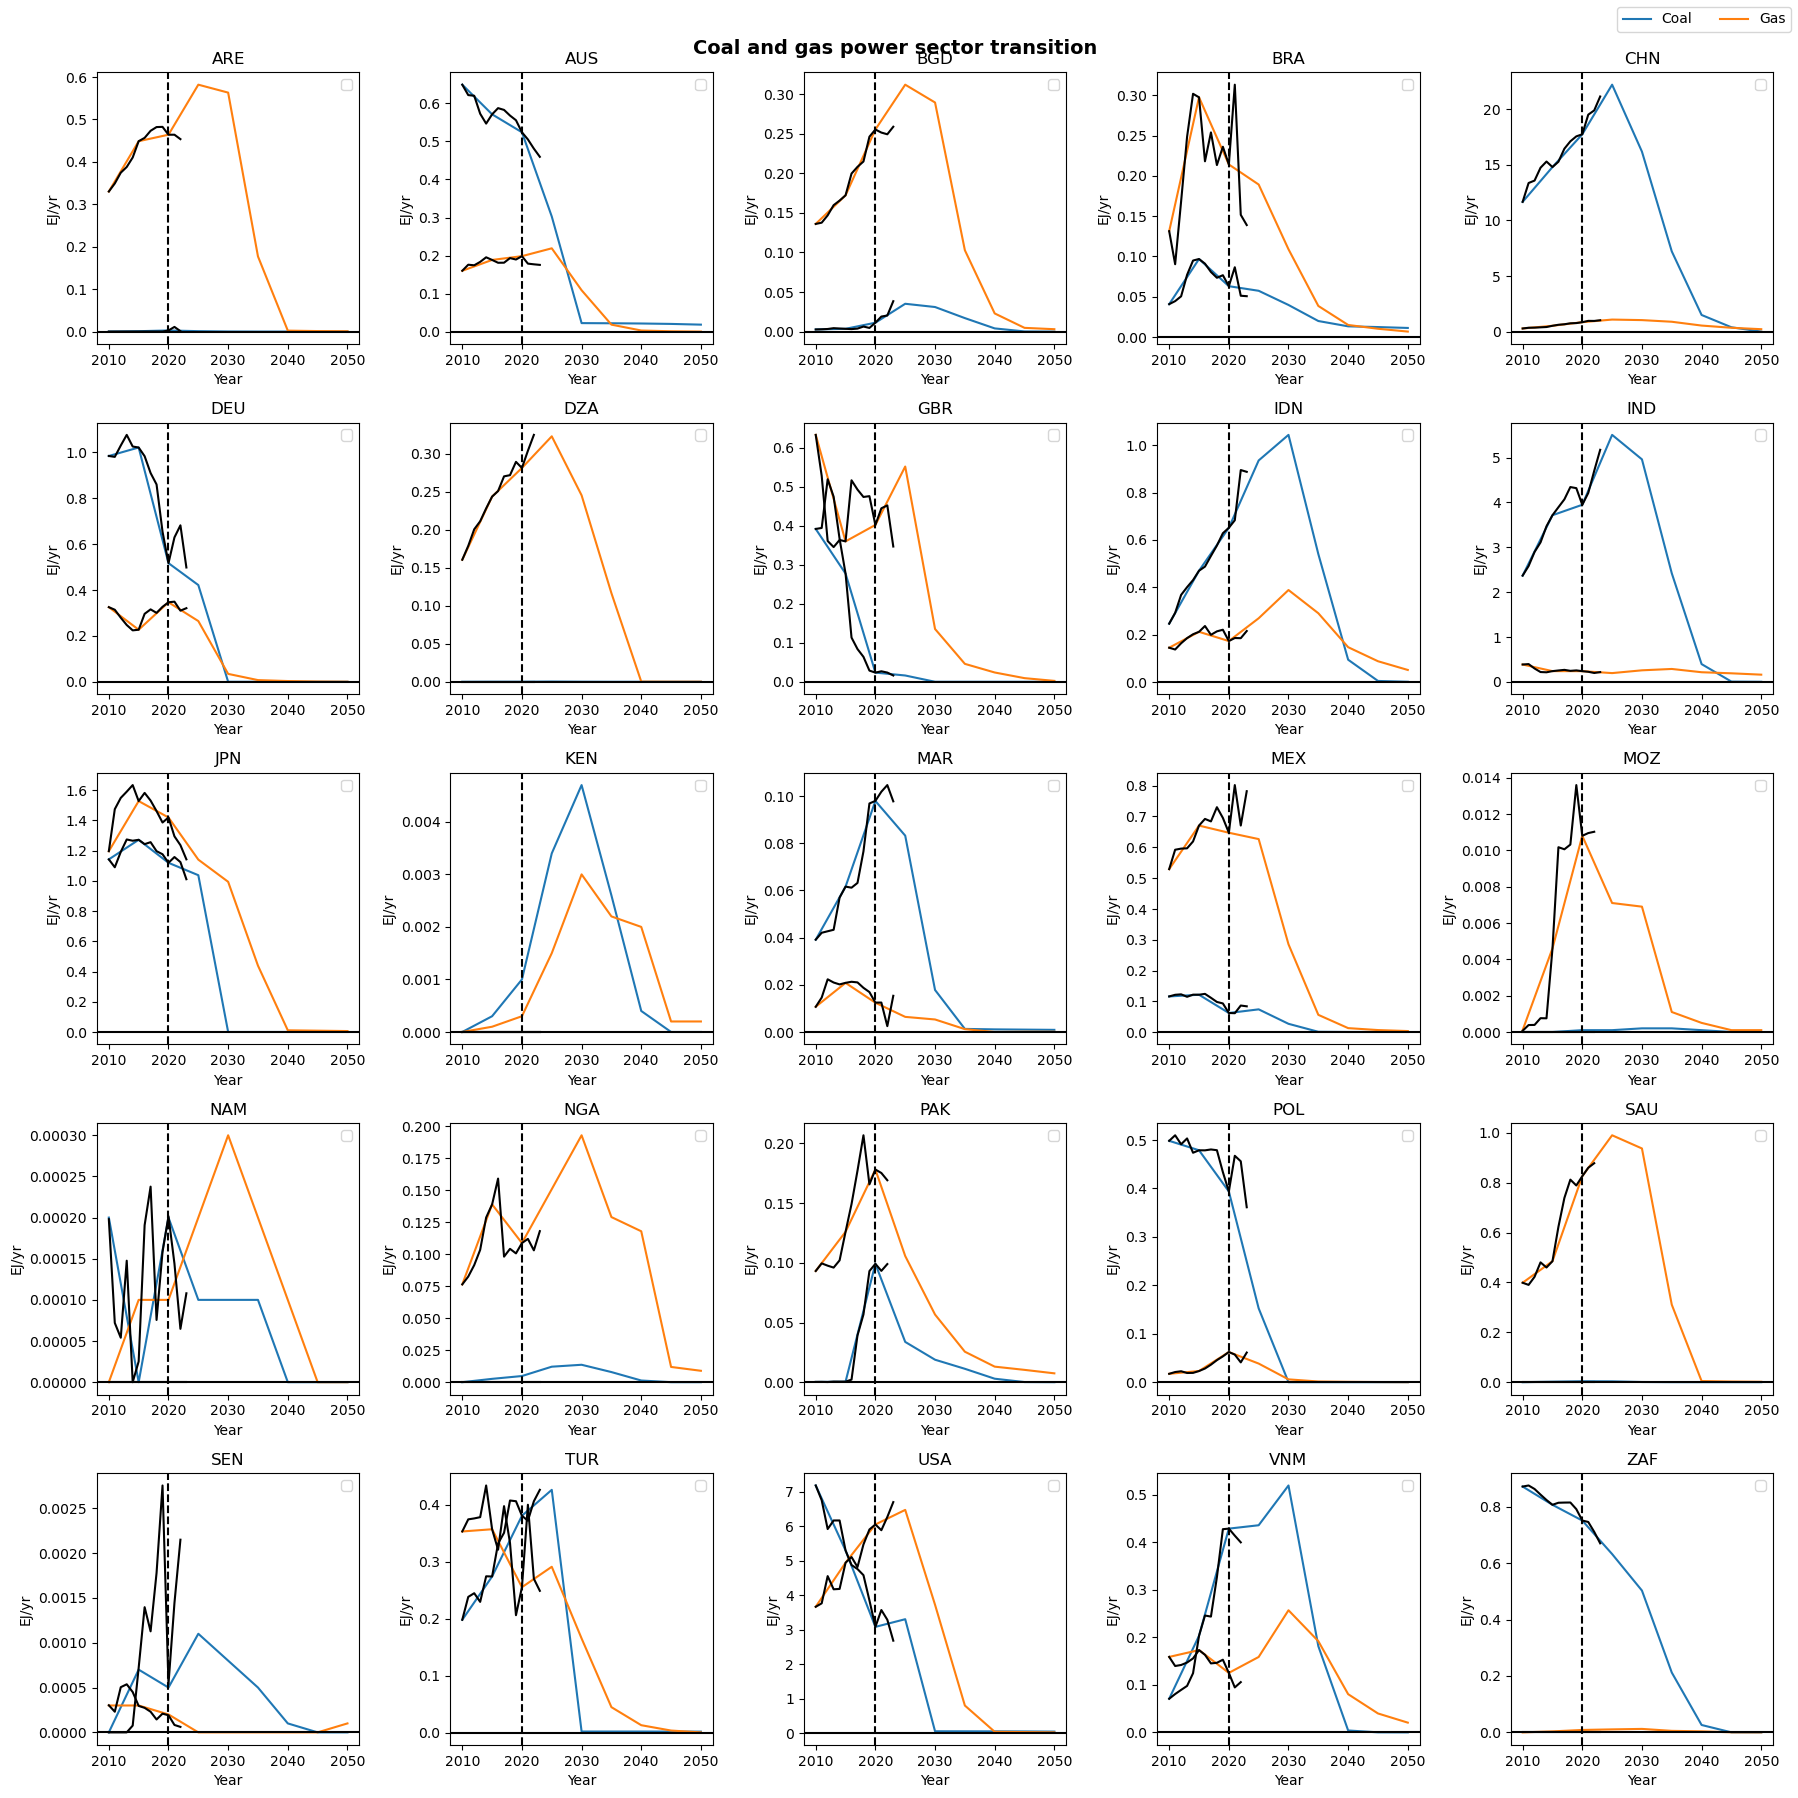

In [19]:
f, axes = plt.subplots(nrows=5,ncols=5,figsize=(18,18))
wns_vars = [elec('Coal'),elec('Gas')]

for count, ax in enumerate(axes.ravel()[:]):
    dscale_results.filter(scenario='NPE-core',region=IKEA_ISOS[count],variable=wns_vars,year=range(2010,2051)).plot(ax=ax)
    hist_data_iea.filter(region=IKEA_ISOS[count],variable=wns_vars,year=range(2010,2025)).plot(ax=ax,color='k')
    ax.axvline(x=2020,color='k',ls='--')
    ax.axhline(y=0,color='k',ls='-')
    ax.set_title(IKEA_ISOS[count])
    ax.legend([])


f.suptitle('Coal and gas power sector transition',fontsize=14,fontweight='bold')
f.legend(['Coal','Gas'],ncols=2)
plt.tight_layout()

## Electricity mix

In [ ]:
year_proj = [2020,
 2025,
 2030,
 2035,
 2040,
 2045,
 2050,
 2055,
 2060,
 2065,
 2070,
 2075,
 2080,
 2085,
 2090,
 2095,
 2100]

f, axes = plt.subplots(nrows=5, ncols=5, figsize=(18, 18))

# colors = [color_map[v] for v in power_mix_var]

for count, ax in enumerate(axes.ravel()):

    dscale_results.filter(
        scenario='NPE-core',
        region=IKEA_ISOS[count],
        variable=power_mix_var,
        year = year_proj
    ).plot.stack(ax=ax,)

    hist_data_iea.filter(
        region=IKEA_ISOS[count],
        variable=power_mix_var,
        year=[2015, 2016, 2017, 2018, 2019]
    ).plot.stack(ax=ax)

    ax.axvline(x=2020, color='k', ls='--')
    ax.set_title(IKEA_ISOS[count])
    ax.legend().remove()

ax.legend()

f.suptitle('Power sector mix',fontsize=14,fontweight='bold')
# f.legend(power_mix_var,ncols=4,loc='center',bbox_to_anchor=[0.5,-0.05])
plt.tight_layout()

In [150]:
power_mix_var

['Secondary Energy|Electricity|Biomass',
 'Secondary Energy|Electricity|Coal',
 'Secondary Energy|Electricity|Gas',
 'Secondary Energy|Electricity|Geothermal',
 'Secondary Energy|Electricity|Hydro',
 'Secondary Energy|Electricity|Nuclear',
 'Secondary Energy|Electricity|Oil',
 'Secondary Energy|Electricity|Solar',
 'Secondary Energy|Electricity|Wind',
 'Secondary Energy|Electricity|Non-Biomass Renewables']

## Comparison with NPE Siamese

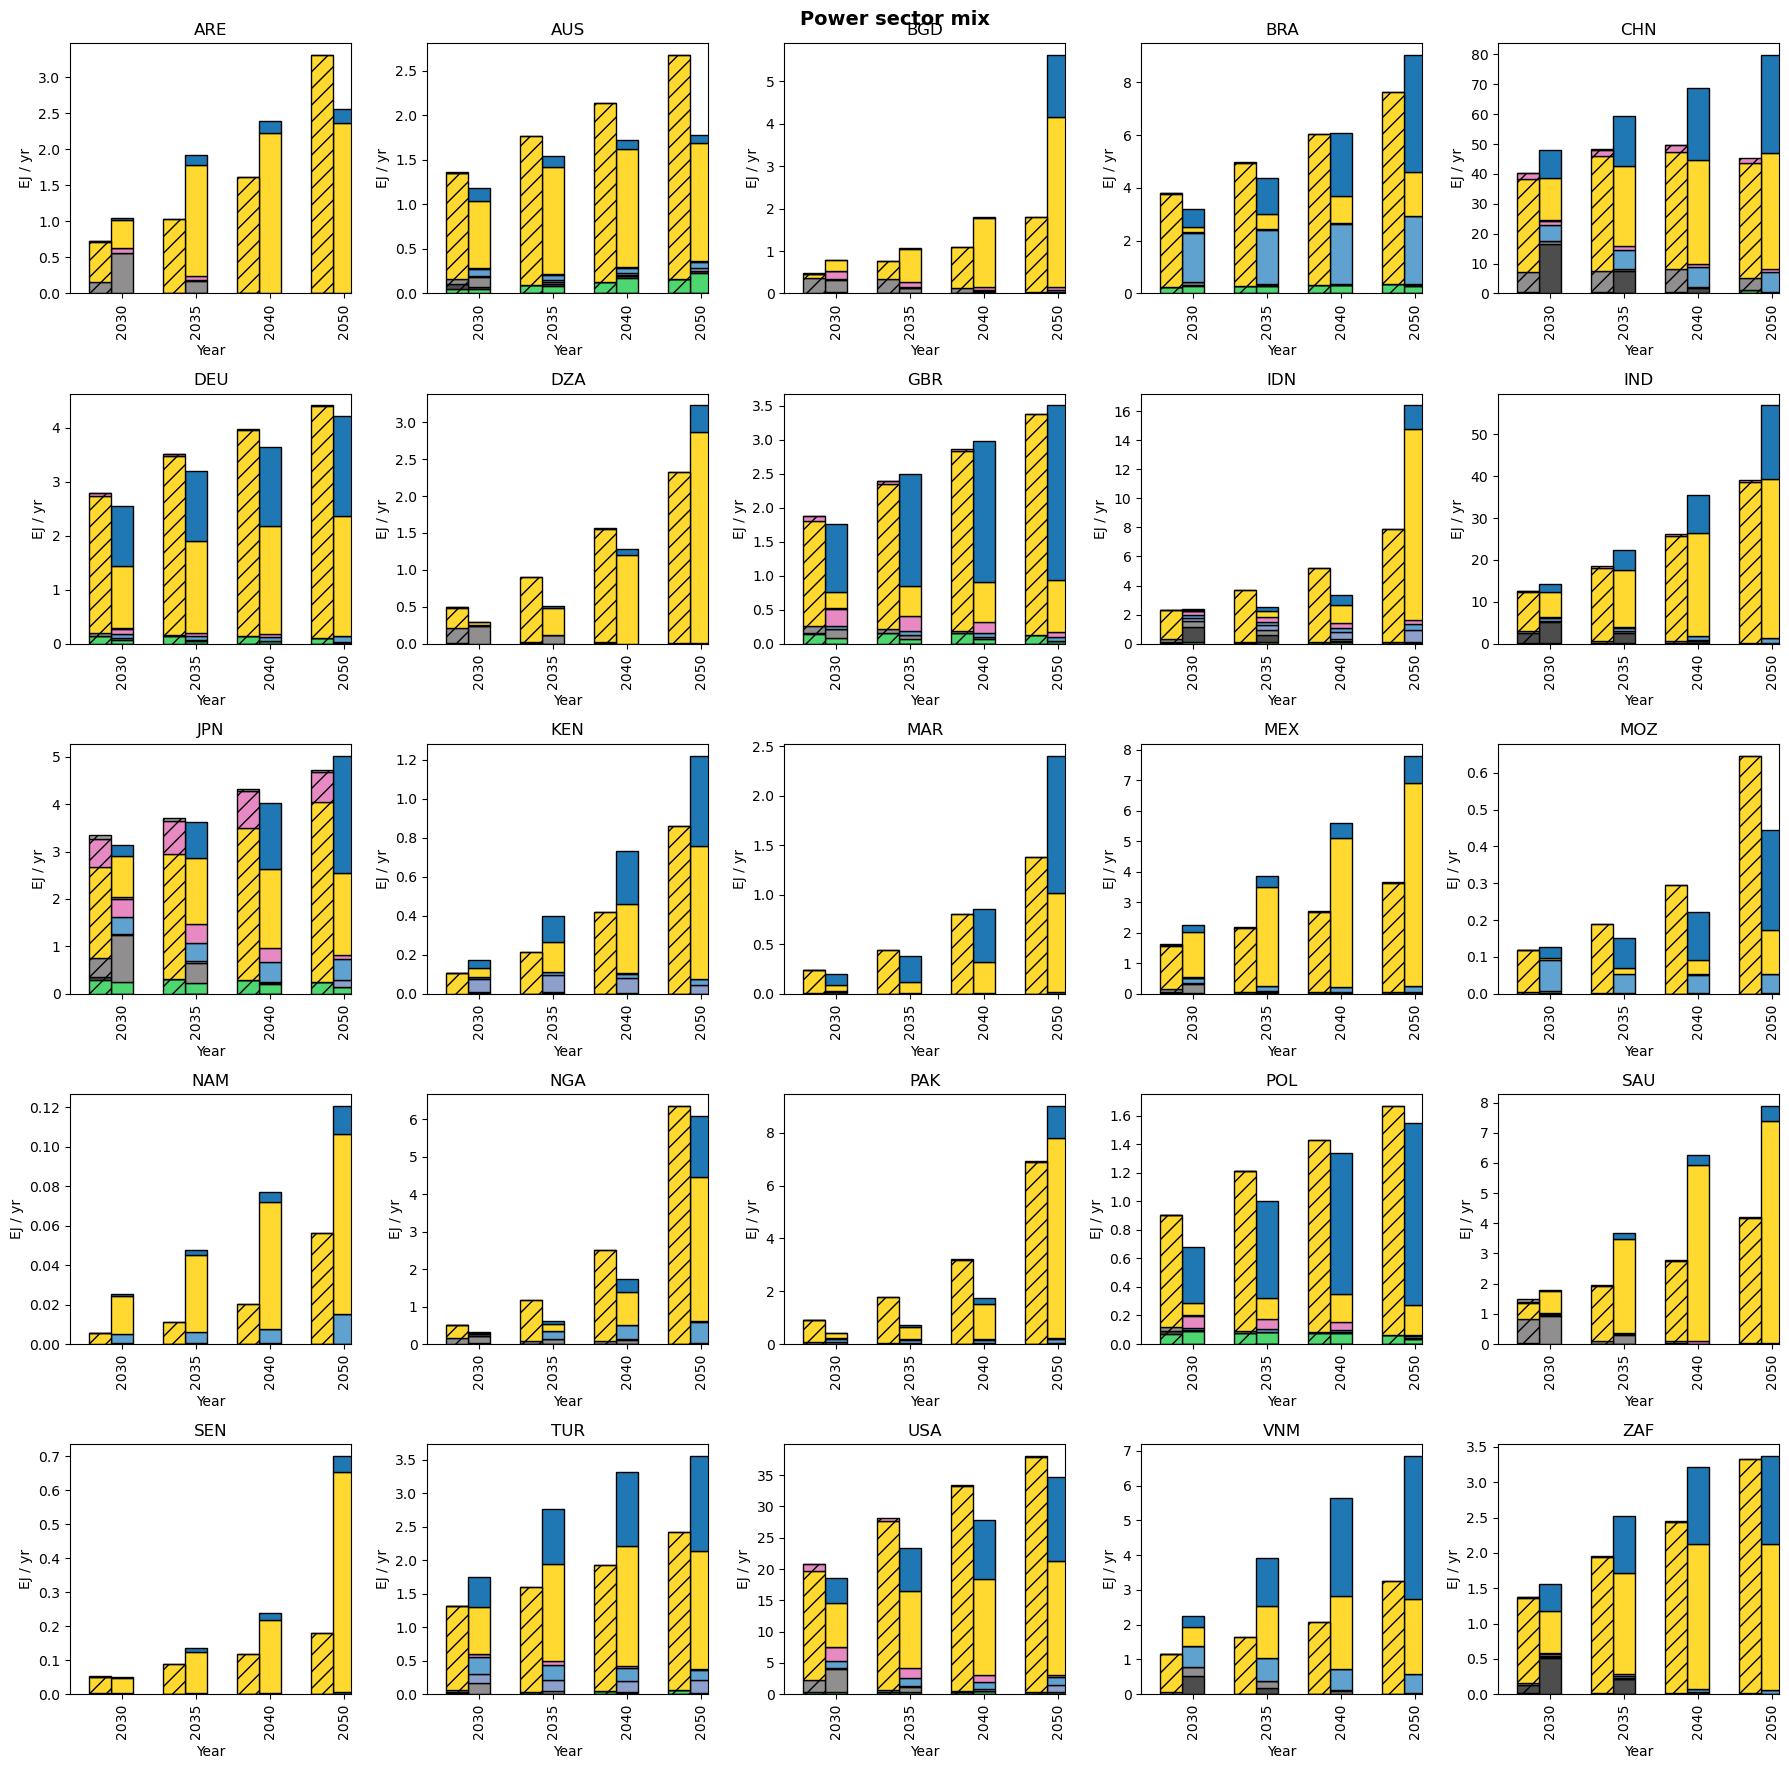

In [124]:


f, axes = plt.subplots(nrows=5, ncols=5, figsize=(18, 18))

# colors = [color_map[v] for v in power_mix_var]

for count, ax in enumerate(axes.ravel()):

    dscale_results.filter(
        year = [2030,2035,2040,2050],
        scenario='NPE-core',
        region=IKEA_ISOS[count],
        variable=power_mix_var[:-1]
    ).plot.bar(stacked=True, ax=ax, width=0.3, edgecolor="k")

    npe_siamese.filter(
        year = [2030,2035,2040,2050], 
        variable = power_mix_var, 
        region = IKEA_ISOS[count], 
        scenario = "*Deep*"
    ).plot.bar(stacked=True, ax = ax, position=1.5, width=0.3, hatch="//", edgecolor="k")

    # ax.axvline(x=2020, color='k', ls='--')
    ax.set_title(IKEA_ISOS[count])
    ax.legend().remove()
    # ax.set_xlim(2020,2060)


f.suptitle('Power sector mix',fontsize=14,fontweight='bold')
# f.legend()
plt.tight_layout()

In [138]:
dscale_results.filter(variable="*Non-CO2*").variable

['Emissions|Total Non-CO2', 'Statistical Difference|Emissions|Total Non-CO2']

In [ ]:
## Variable to check for sector
# Proiority
"Primary Energy*"
"Final Energy|Transportation*"
# next to the list
"Final Energy|Industry*"
"Final Energy|Residential and Commercial*"

In [139]:
power_mix_var

['Secondary Energy|Electricity|Biomass',
 'Secondary Energy|Electricity|Coal',
 'Secondary Energy|Electricity|Gas',
 'Secondary Energy|Electricity|Geothermal',
 'Secondary Energy|Electricity|Hydro',
 'Secondary Energy|Electricity|Nuclear',
 'Secondary Energy|Electricity|Oil',
 'Secondary Energy|Electricity|Solar',
 'Secondary Energy|Electricity|Wind',
 'Secondary Energy|Electricity|Non-Biomass Renewables']

In [140]:
# Compute shares
for var in power_mix_var:
    dscale_results.divide(
        var, 
        'Secondary Energy|Electricity', 
        var+"|share", 
        unit= "%"
        append=True, 
    )


In [144]:
from pyam import cross_threshold

In [149]:
dscale_results.filter(variable = "*Coal|share", region = "USA").timeseries()

,,,,,2010,2015,2020,2025,2030,2035,2040,2045,2050,2055,2060,2065,2070,2075,2080,2085,2090,2095,2100
model,scenario,region,variable,unit,,,,,,,,,,,,,,,,,,,
REMIND 3.4,NPE-core,USA,Secondary Energy|Electricity|Coal|share,,0.459609,0.352868,0.207575,0.181237,0.002968,0.002334,0.001898,0.001573,0.001319,0.001081,0.000765,0.000409,0.000038,0.00002,0.0,0.0,0.0,0.0,0.0


## Electricity emissions - we don't have them yet